In [ ]:
from langgraph.graph import StateGraph,END,START
from typing import TypedDict

In [ ]:
class BMIState(TypedDict):
    height_kg: float
    weight_kg: float
    bmi: float
    category: str

In [ ]:
def calculate_bmi(state: BMIState) -> BMIState:
    height_m = state["height_kg"] / 100
    bmi = state["weight_kg"] / (height_m ** 2)
    state["bmi"] = round(bmi, 2)
    return state
    

In [25]:
def label_bmi_category(state: BMIState) -> BMIState:
    bmi = state["bmi"]
    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 24.9:
        state["category"] = "Normal weight"
    elif 25 <= bmi < 29.9:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obesity"
    return state

In [29]:
# define the graph
graph = StateGraph(BMIState)
# add nodes to graph

graph.add_node("calculate_bmi", calculate_bmi)
graph.add_edge(START, "calculate_bmi")
graph.add_node("label_bmi_category", label_bmi_category)
graph.add_edge("calculate_bmi", "label_bmi_category")
graph.add_edge("label_bmi_category", END)

workflow = graph.compile()

In [27]:
initial_state = {"height_kg": 170, "weight_kg": 65}
final_state = workflow.invoke(initial_state)
print(final_state)  # Output: {'height_kg': 170, 'weight_kg': 65, 'bmi': 22.49}

{'height_kg': 170, 'weight_kg': 65, 'bmi': 22.49, 'category': 'Normal weight'}


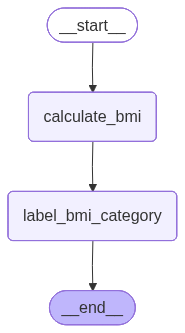

In [28]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())